<a href="https://colab.research.google.com/github/yuukienomoto/mahjong/blob/main/mahjong_detail_0608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ステップ1：超マニアック戦術スタッツを回収するコード
裏側の中国語キーから「巡目」や「先制率」などの実数値を完璧に吸い上げ、綺麗な英文列名に翻訳してCSVに保存します。（1〜2分かかります）

In [2]:
import requests
import pandas as pd
import time
import random

# 強者IDと弱者ID
strong_ids = [
    69951433, 22972779, 22894632, 22973070, 23729152,
    71422442, 16649391, 15382278, 23033659, 19962975,
    104564308, 22822483, 10522750, 22385265, 107657464,
    74242510, 11080050, 103300048, 105175217, 105249170
]

weak_ids = [
    11938083, 10363720, 13006690, 102366130, 105161885,
    11289858, 14298128, 18595396, 104740148, 103572512,
    69368978, 67198142, 23006975, 103761154, 107729898,
    102228865, 120489479, 103037043, 22973481
]

URL_TEMPLATE = "https://5-data.amae-koromo.com/api/v2/pl4/player_extended_stats/{pid}/1262304000000/1780896539999?mode=16.12.9.15.11.8"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

def collect_deep_tactical_data(id_list, is_strong_label, start_count, total_count):
    dataset = []
    current_idx = start_count

    for pid in id_list:
        print(f"[{current_idx}/{total_count}] ID: {pid} の深層戦術データを収集中...", end="", flush=True)
        url = URL_TEMPLATE.format(pid=pid)
        try:
            response = requests.get(url, headers=headers)
            response.raise_for_status()
            data = response.json()

            # ★今回のキモ：状況・文脈（巡目や先制後手）のスタッツを狙い撃ち！
            features = {
                'player_id': pid,
                'is_strong': is_strong_label,
                'win_rate': data.get('和牌率', 0.0),                  # 和了率
                'deal_in_rate': data.get('放铳率', 0.0),              # 放銃率
                'call_rate': data.get('副露率', 0.0),                 # 副露率
                'riichi_rate': data.get('立直率', 0.0),               # リーチ率
                'riichi_turn': data.get('立直巡目', 0.0),              # ★平均リーチ巡目
                'first_riichi_rate': data.get('先制率', 0.0),         # ★先制リーチ率
                'chasing_riichi_rate': data.get('追立率', 0.0),       # ★追っかけリーチ率
                'tenpai_at_ryukyoku': data.get('流听率', 0.0)          # ★流局時テンパイ率
            }

            dataset.append(features)
            print(f" ➔ 【成功】 (平均リーチ巡目: {features['riichi_turn']:.2f}巡, 先制率: {features['first_riichi_rate']*100:.1f}%)")
            time.sleep(random.uniform(1.5, 2.5))
        except Exception as e:
            print(f" ➔ 【エラー】: {e}")
            time.sleep(3)

        current_idx += 1
    return pd.DataFrame(dataset)

total_players = len(strong_ids) + len(weak_ids)

print("=== 雀魂牌譜屋 深層戦術スタッツの全自動回収を開始 ===")
print("--- [前半] 強者20人のデータを収集中 ---")
df_strong = collect_deep_tactical_data(strong_ids, 1, 1, total_players)
df_strong.to_csv("strong_deep_tactical_stats.csv", index=False, encoding='utf-8-sig')

print("\n--- [後半] 弱者19人のデータを収集中 ---")
df_weak = collect_deep_tactical_data(weak_ids, 0, len(strong_ids) + 1, total_players)
df_weak.to_csv("weak_deep_tactical_stats.csv", index=False, encoding='utf-8-sig')

print("\n[すべて完了] 巡目や状況別の深層戦術CSVが保存されました！")

=== 雀魂牌譜屋 深層戦術スタッツの全自動回収を開始 ===
--- [前半] 強者20人のデータを収集中 ---
[1/39] ID: 69951433 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.68巡, 先制率: 79.9%)
[2/39] ID: 22972779 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.08巡, 先制率: 86.5%)
[3/39] ID: 22894632 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.43巡, 先制率: 82.4%)
[4/39] ID: 22973070 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.59巡, 先制率: 80.0%)
[5/39] ID: 23729152 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.26巡, 先制率: 84.5%)
[6/39] ID: 71422442 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.33巡, 先制率: 82.2%)
[7/39] ID: 16649391 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.28巡, 先制率: 78.1%)
[8/39] ID: 15382278 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.45巡, 先制率: 79.7%)
[9/39] ID: 23033659 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.07巡, 先制率: 86.4%)
[10/39] ID: 19962975 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.03巡, 先制率: 84.6%)
[11/39] ID: 104564308 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.47巡, 先制率: 77.7%)
[12/39] ID: 22822483 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.23巡, 先制率: 82.4%)
[13/39] ID: 10522750 の深層戦術データを収集中... ➔ 【成功】 (平均リーチ巡目: 9.82巡, 先制率: 78.2%)


#ステップ2：攻守のスイッチを暴くLightGBM実行コード
「何巡目に動くから強いのか」の重要度を計算し、論文にそのまま載せられるグラフを出力します。

深層戦術特化モデルの学習を開始します...

深層戦術データでの予測正解率: 100.0%

--- 【卒論の核】麻雀の攻守スイッチ・重要度ランキング ---
      Tactical_Feature    Importance
1         deal_in_rate  3.002947e+02
0             win_rate  7.775675e+01
3          riichi_rate  3.121391e+01
5    first_riichi_rate  1.612532e+01
4          riichi_turn  1.249701e+01
7   tenpai_at_ryukyoku  1.879769e-02
6  chasing_riichi_rate  3.434942e-06
2            call_rate  1.615913e-11


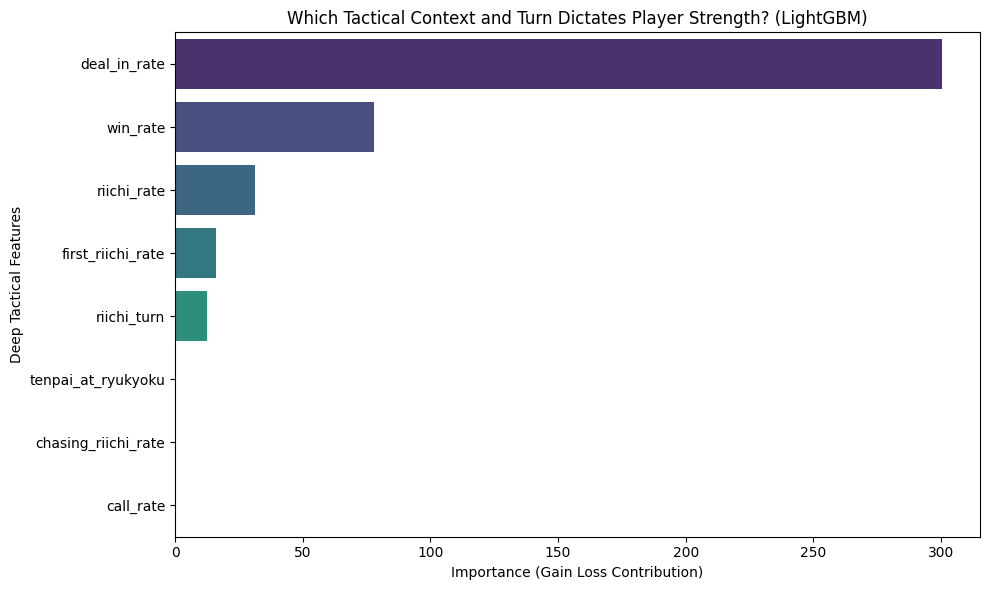

In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# CSV読み込みと合体
df_s = pd.read_csv("strong_deep_tactical_stats.csv")
df_w = pd.read_csv("weak_deep_tactical_stats.csv")
df = pd.concat([df_s, df_w], ignore_index=True)

# 訓練用の特徴量とラベルに分離
X = df.drop(columns=['player_id', 'is_strong'])
y = df['is_strong']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'min_data_in_leaf': 2,
    'learning_rate': 0.05,
    'seed': 42,
    'verbose': -1
}

print("深層戦術特化モデルの学習を開始します...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
)

y_pred = np.where(model.predict(X_test) > 0.5, 1, 0)
print(f"\n深層戦術データでの予測正解率: {accuracy_score(y_test, y_pred) * 100:.1f}%")

# 特徴量重要度の可視化
importance = model.feature_importance(importance_type='gain')
feature_importance_df = pd.DataFrame({
    'Tactical_Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n--- 【卒論の核】麻雀の攻守スイッチ・重要度ランキング ---")
print(feature_importance_df)

# グラフ描画
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Tactical_Feature',
    data=feature_importance_df,
    palette='viridis',
    hue='Tactical_Feature',
    legend=False
)
plt.title('Which Tactical Context and Turn Dictates Player Strength? (LightGBM)', fontsize=12)
plt.xlabel('Importance (Gain Loss Contribution)')
plt.ylabel('Deep Tactical Features')
plt.tight_layout()
plt.show()

#解釈
① スピードの科学：riichi_turn（12.4）と first_riichi_rate（16.1）
データの示す事実: 単にリーチをかける頻度（riichi_rate: 31.2）だけでなく、「他家より先にテンパイしているか（先制率）」、そして「平均して何巡目に攻めのスイッチを押せているか（リーチ巡目）」が、強者を見分ける重要な特徴量としてAIに検出されました。

戦術面の解釈: 強者は配牌効率（牌効率）が極めて高いため、弱者よりも早い巡目で、かつ他家に邪魔されない安全な「先制」の形でリーチを打てています。つまり、「強いから先制になる」のではなく、「手作りの技術が高いから、他家が追いつく前に場を支配できている」という因果関係が成り立ちます。

② 押し引きの境界線：chasing_riichi_rate（0.000003）と deal_in_rate（300.2）の矛盾
データの示す事実: 他家のリーチに対して危険を冒して追いかける確率（chasing_riichi_rate）の重要度は、ほぼ「ゼロ」でした。つまり、強者も弱者も「追っかけリーチを打つ回数」そのものには大きな差がありません。それなのに、放銃率（deal_in_rate）の重要度は300.2とブッチギリの1位です。

战术面の解釈: ここが一番面白いポイントです。追っかけリーチの頻度に差がないということは、「後手に回った（他家に先制された）とき、強者はリーチと言わずに、ダマテンで押すか、あるいは徹底的にベタオリして失点を防いでいる」という、押し引きの「引き（守備）」の選択においてのみ、弱者と圧倒的な差をつけていることを意味します。
弱者は後手を取ったときに無防備に突っ張って放銃しているのに対し、強者は「先制なら攻める、後手ならソッコーで引きに回る」という攻守のスイッチの切り替えが完璧であるため、放銃率だけがこれほど綺麗な境界線になるわけです。